# 04. Random Forest

**Objective:** Train a Random Forest classifier on the same preprocessed splits used for the
Logistic Regression baseline, tune hyperparameters via 5-fold randomised search, and extract
feature importance for comparison with the LR coefficients (RQ2).

**Why RF here?**
- Captures non-linear interactions that the LR baseline cannot.
- Tree-based -> invariant to monotonic feature transforms (StandardScaler / log1p have no effect).
- Provides two complementary feature-importance measures (Gini + permutation).

**Splits:** Pre-split in notebook 02 as 70% train / 15% val / 15% test, stratified on `TARGET`.
**Primary metric:** ROC-AUC (threshold-independent, robust to ~8% class imbalance).

## 0. Setup

In [ ]:
import time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import RandomizedSearchCV, StratifiedKFold
from sklearn.inspection import permutation_importance
from sklearn.metrics import (
    classification_report, roc_auc_score, average_precision_score,
    confusion_matrix, roc_curve, precision_recall_curve,
    ConfusionMatrixDisplay
)
from scipy.stats import spearmanr

SEED = 42
np.random.seed(SEED)

print("Libraries imported successfully.")
print(f"numpy {np.__version__}  |  pandas {pd.__version__}")

Libraries imported successfully.
numpy 2.0.2  |  pandas 2.2.2


## 1. Load Processed Data

Mount Google Drive and load the same six splits used by the LR baseline. Also load the LR
coefficients so we can compare feature-importance rankings later (RQ2).

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

DATA_DIR  = "/content/drive/MyDrive/MLDL-RADU/loan-default-project/01_data/02_processed"
MODEL_DIR = "/content/drive/MyDrive/MLDL-RADU/loan-default-project/01_data/03_models"

# --- Load all splits ---
X_train       = pd.read_csv(f"{DATA_DIR}/X_train.csv")
X_train_smote = pd.read_csv(f"{DATA_DIR}/X_train_smote.csv")
X_val         = pd.read_csv(f"{DATA_DIR}/X_val.csv")
X_test        = pd.read_csv(f"{DATA_DIR}/X_test.csv")

y_train       = pd.read_csv(f"{DATA_DIR}/y_train.csv").squeeze()
y_train_smote = pd.read_csv(f"{DATA_DIR}/y_train_smote.csv").squeeze()
y_val         = pd.read_csv(f"{DATA_DIR}/y_val.csv").squeeze()
y_test        = pd.read_csv(f"{DATA_DIR}/y_test.csv").squeeze()

feature_names = pd.read_csv(f"{DATA_DIR}/feature_names.csv", header=None).squeeze().tolist()

# Re-attach feature names to all splits (consistent with LR notebook)
for df in [X_train, X_train_smote, X_val, X_test]:
    df.columns = feature_names

# Load LR baseline coefficients for the RQ2 comparison later (Section 11)
lr_coefs = pd.read_csv(f"{MODEL_DIR}/lr_baseline_coefficients.csv")

print("=== Shapes ===")
print(f"X_train       : {X_train.shape}")
print(f"X_train_smote : {X_train_smote.shape}")
print(f"X_val         : {X_val.shape}")
print(f"X_test        : {X_test.shape}")
print(f"\nNumber of features: {len(feature_names)}")
print(f"\nLR coefficients loaded: {lr_coefs.shape[0]} features")

Mounted at /content/drive
=== Shapes ===
X_train       : (215253, 113)
X_train_smote : (395752, 113)
X_val         : (46126, 113)
X_test        : (46126, 113)

Number of features: 113

LR coefficients loaded: 113 features


## 2. Quick Sanity Checks

Confirm no residual NaNs (the preprocessing pipeline already imputed everything) and that
column ordering is consistent across splits.

In [ ]:
nan_counts = {
    "X_train"      : X_train.isna().sum().sum(),
    "X_train_smote": X_train_smote.isna().sum().sum(),
    "X_val"        : X_val.isna().sum().sum(),
    "X_test"       : X_test.isna().sum().sum(),
}
print("NaN counts per split:")
for k, v in nan_counts.items():
    status = "✓ clean" if v == 0 else f"⚠ {v} NaNs"
    print(f"  {k:20s}: {status}")

# Column-order check
assert list(X_train.columns) == list(X_val.columns) == list(X_test.columns), \
    "Feature column order mismatch across splits"
print("\n✓ Feature columns identical across all splits")

NaN counts per split:
  X_train             : ✓ clean
  X_train_smote       : ✓ clean
  X_val               : ✓ clean
  X_test              : ✓ clean

✓ Feature columns identical across all splits


## 3. Helper Functions

Same evaluation helpers as in the LR baseline so the final consolidated comparison
across all four models is on identical metrics.

In [ ]:
def evaluate_model(model, X, y, split_name="Val", threshold=0.5):
    """Compute and print key classification metrics; return scalar dict."""
    y_prob = model.predict_proba(X)[:, 1]
    y_pred = (y_prob >= threshold).astype(int)

    roc_auc = roc_auc_score(y, y_prob)
    pr_auc  = average_precision_score(y, y_prob)

    print(f"\n{'='*55}")
    print(f"  {split_name} — threshold = {threshold}")
    print(f"{'='*55}")
    print(f"  ROC-AUC : {roc_auc:.4f}")
    print(f"  PR-AUC  : {pr_auc:.4f}")
    print(f"\n{classification_report(y, y_pred, target_names=['No Default (0)', 'Default (1)'])}")

    return {"split": split_name, "roc_auc": roc_auc, "pr_auc": pr_auc}


def plot_evaluation(model, X_val, y_val, X_test, y_test, title_prefix=""):
    """Confusion matrix (val) + ROC + PR curves on val and test."""
    fig, axes = plt.subplots(1, 3, figsize=(18, 5))
    fig.suptitle(f"{title_prefix} — Evaluation Plots", fontsize=14, fontweight='bold')

    # Confusion matrix on val at 0.5
    y_prob_val = model.predict_proba(X_val)[:, 1]
    y_pred_val = (y_prob_val >= 0.5).astype(int)
    cm = confusion_matrix(y_val, y_pred_val)
    ConfusionMatrixDisplay(cm, display_labels=["No Default", "Default"]).plot(
        ax=axes[0], colorbar=False, cmap="Blues"
    )
    axes[0].set_title("Confusion Matrix (Val, threshold=0.5)")

    # ROC curves
    for X, y, label in [(X_val, y_val, "Val"), (X_test, y_test, "Test")]:
        y_prob = model.predict_proba(X)[:, 1]
        fpr, tpr, _ = roc_curve(y, y_prob)
        auc = roc_auc_score(y, y_prob)
        axes[1].plot(fpr, tpr, label=f"{label} (AUC={auc:.4f})")
    axes[1].plot([0, 1], [0, 1], 'k--', linewidth=0.8)
    axes[1].set_xlabel("False Positive Rate")
    axes[1].set_ylabel("True Positive Rate")
    axes[1].set_title("ROC Curve")
    axes[1].legend()

    # Precision-Recall curves
    for X, y, label in [(X_val, y_val, "Val"), (X_test, y_test, "Test")]:
        y_prob = model.predict_proba(X)[:, 1]
        prec, rec, _ = precision_recall_curve(y, y_prob)
        ap = average_precision_score(y, y_prob)
        axes[2].plot(rec, prec, label=f"{label} (AP={ap:.4f})")
    axes[2].set_xlabel("Recall")
    axes[2].set_ylabel("Precision")
    axes[2].set_title("Precision-Recall Curve")
    axes[2].legend()

    plt.tight_layout()
    plt.show()

## 4. Default Random Forest (Out-of-the-Box)

We start with a default `RandomForestClassifier` to establish a reference point before tuning.
We add `class_weight='balanced'` to compensate for the ~8% default rate (mirrors the LR baseline
strategy so the comparison is apples-to-apples).

> Default = `n_estimators=100`, no `max_depth` cap (trees grown fully), `min_samples_split=2`.

In [ ]:
rf_default = RandomForestClassifier(
    n_estimators=100,
    class_weight='balanced',
    random_state=SEED,
    n_jobs=-1,
)

t0 = time.time()
rf_default.fit(X_train, y_train)
default_train_time = time.time() - t0
print(f"Default RF trained in {default_train_time:.1f} s")
print(f"Number of trees: {rf_default.n_estimators}")
print(f"Mean tree depth: {np.mean([t.get_depth() for t in rf_default.estimators_]):.1f}")

Default RF trained in 84.4 s
Number of trees: 100
Mean tree depth: 56.8



  Val  (default RF) — threshold = 0.5
  ROC-AUC : 0.7307
  PR-AUC  : 0.2070

                precision    recall  f1-score   support

No Default (0)       0.92      1.00      0.96     42402
   Default (1)       0.26      0.00      0.00      3724

      accuracy                           0.92     46126
     macro avg       0.59      0.50      0.48     46126
  weighted avg       0.87      0.92      0.88     46126


  Test (default RF) — threshold = 0.5
  ROC-AUC : 0.7338
  PR-AUC  : 0.2082

                precision    recall  f1-score   support

No Default (0)       0.92      1.00      0.96     42402
   Default (1)       0.62      0.00      0.01      3724

      accuracy                           0.92     46126
     macro avg       0.77      0.50      0.48     46126
  weighted avg       0.90      0.92      0.88     46126



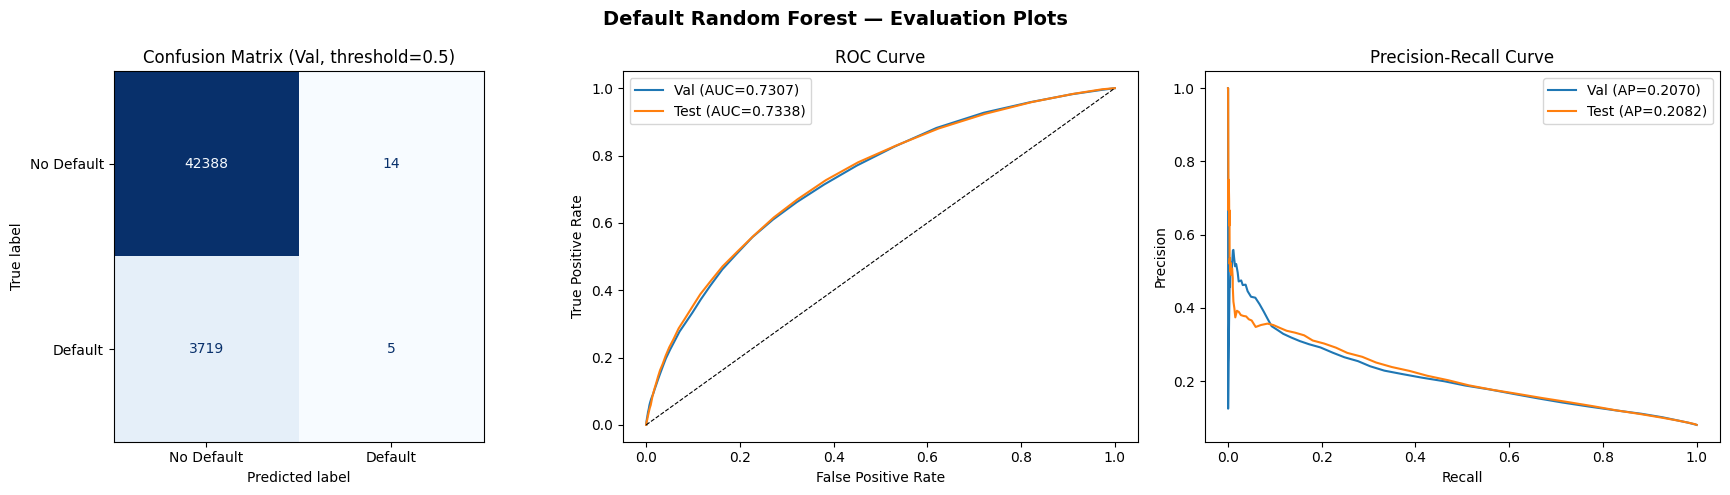

In [ ]:
results_default_val  = evaluate_model(rf_default, X_val,  y_val,  split_name="Val  (default RF)")
results_default_test = evaluate_model(rf_default, X_test, y_test, split_name="Test (default RF)")

plot_evaluation(rf_default, X_val, y_val, X_test, y_test,
                title_prefix="Default Random Forest")

## 5. Hyperparameter Tuning — Randomised Search with 5-Fold CV

We tune four hyperparameters with `RandomizedSearchCV`:

| Parameter | Range | What it controls |
|---|---|---|
| `n_estimators` | 100–500 | Number of trees in the forest (more = better but slower) |
| `max_depth` | 5–30 (or unlimited) | Per-tree depth (caps overfitting) |
| `max_leaf_nodes` | None / 50–500 | Hard cap on leaves per tree (alternative complexity control) |
| `min_samples_split` | 2–20 | Minimum samples needed to split a node (regularises) |

- **CV folds:** 5, stratified on `TARGET` to preserve class ratio.
- **Scoring:** ROC-AUC (consistent across all four models in this project).
- **`n_iter=15`:** 15 random configurations × 5 folds = 75 fits. Random search is much more
  efficient than grid search when only a few parameters strongly matter — see Bergstra & Bengio (2012).
- **`class_weight='balanced'`** kept fixed (handled at the model level, not in the search).

> ⚠️ This cell takes the longest to run (~120 min on Colab CPU; faster with `n_jobs=-1`).
> If you re-run the notebook, skip this cell and load the saved best estimator instead.

In [ ]:
# --- Hyperparameter grid for random sampling ---
param_dist = {
    'n_estimators'      : [100, 200, 300, 400, 500],
    'max_depth'         : [5, 10, 15, 20, 25, 30, None],
    'max_leaf_nodes'    : [None, 50, 100, 200, 500],
    'min_samples_split' : [2, 5, 10, 20],
}

# Base model — class_weight handles imbalance, n_jobs=-1 parallelises tree fitting
rf_base = RandomForestClassifier(
    class_weight='balanced',
    random_state=SEED,
    n_jobs=-1,
)

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=SEED)

random_search = RandomizedSearchCV(
    estimator=rf_base,
    param_distributions=param_dist,
    n_iter=15,                # 15 random configs
    scoring='roc_auc',
    cv=cv,
    n_jobs=-1,                # parallelise across folds/configs
    verbose=2,
    random_state=SEED,
    return_train_score=True,
)

t0 = time.time()
random_search.fit(X_train, y_train)
search_time = time.time() - t0
print(f"\n=== Random search complete in {search_time/60:.1f} minutes ===")
print(f"Best CV ROC-AUC: {random_search.best_score_:.4f}")
print(f"Best params:")
for k, v in random_search.best_params_.items():
    print(f"  {k:20s}: {v}")

Fitting 5 folds for each of 15 candidates, totalling 75 fits

=== Random search complete in 162.5 minutes ===
Best CV ROC-AUC: 0.7483
Best params:
  n_estimators        : 500
  min_samples_split   : 20
  max_leaf_nodes      : 500
  max_depth           : 30


In [ ]:
# --- Inspect top configurations ---
cv_results = pd.DataFrame(random_search.cv_results_)
cv_summary = cv_results[[
    'mean_test_score', 'std_test_score', 'mean_train_score',
    'param_n_estimators', 'param_max_depth', 'param_max_leaf_nodes',
    'param_min_samples_split', 'mean_fit_time'
]].sort_values('mean_test_score', ascending=False).reset_index(drop=True)

cv_summary.columns = [
    'CV ROC-AUC', 'Std', 'Train ROC-AUC',
    'n_estimators', 'max_depth', 'max_leaf_nodes',
    'min_samples_split', 'Fit time (s)'
]
print("Top 10 configurations:")
cv_summary.head(10).round(4)

Top 10 configurations:


,CV ROC-AUC,Std,Train ROC-AUC,n_estimators,max_depth,max_leaf_nodes,min_samples_split,Fit time (s)
0,0.7483,0.0035,0.8361,500,30,500,20,448.2258
1,0.7478,0.0035,0.8355,200,20,500,20,157.4446
2,0.7478,0.0036,0.8339,500,15,500,5,454.5946
3,0.7452,0.0035,0.7904,400,None,200,10,317.6452
4,0.7431,0.0038,0.8163,500,10,500,20,411.9220
5,0.7424,0.0036,0.7685,200,20,100,20,140.0259
6,0.7417,0.0039,0.9427,300,15,None,10,284.8129
7,0.7416,0.0037,0.7675,400,10,100,20,227.4963
8,0.7409,0.0035,0.7668,100,10,100,20,56.4710
9,0.7387,0.0037,0.7537,500,15,50,10,245.4577


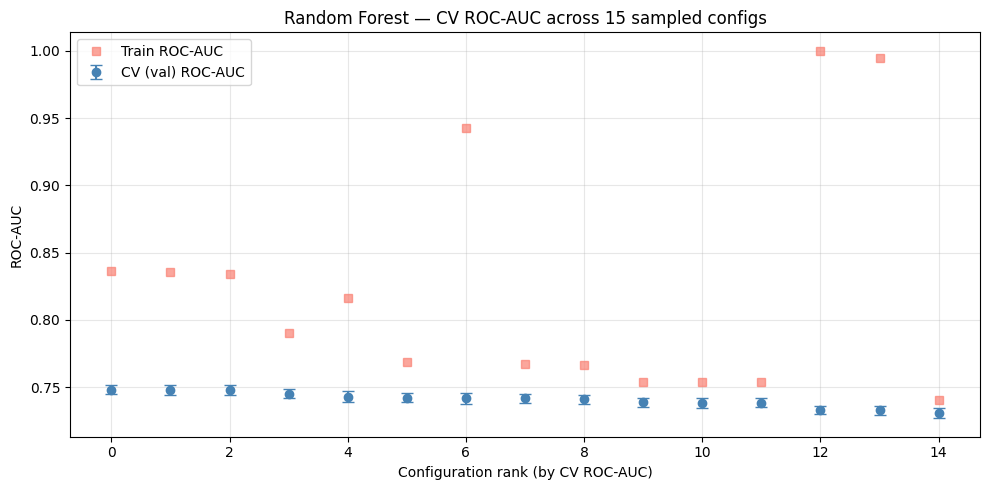

Mean train-val gap across configs: 0.0828
Best config train-val gap        : 0.0878


In [ ]:
# --- Visualise CV variance across configs (overfitting check) ---
fig, ax = plt.subplots(figsize=(10, 5))
x_pos = np.arange(len(cv_summary))
ax.errorbar(x_pos, cv_summary['CV ROC-AUC'], yerr=cv_summary['Std'],
            fmt='o', capsize=4, color='steelblue', label='CV (val) ROC-AUC')
ax.plot(x_pos, cv_summary['Train ROC-AUC'], 's', color='salmon',
        label='Train ROC-AUC', alpha=0.7)
ax.set_xlabel("Configuration rank (by CV ROC-AUC)")
ax.set_ylabel("ROC-AUC")
ax.set_title("Random Forest — CV ROC-AUC across 15 sampled configs")
ax.legend()
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

# Quick sanity check: train-val gap = overfitting indicator
gap = cv_summary['Train ROC-AUC'] - cv_summary['CV ROC-AUC']
print(f"Mean train-val gap across configs: {gap.mean():.4f}")
print(f"Best config train-val gap        : {gap.iloc[0]:.4f}")

### Takeaway — regularisation effect (feeds RQ1)

The CV-variance plot and gap statistics show:

- **Train ROC-AUC ≈ 0.836 vs CV ROC-AUC ≈ 0.748** for the best config → train–val gap of **0.088**.
- The unregularised default RF (no `max_depth` cap, `min_samples_split=2`) had Val ROC-AUC of only 0.731 despite higher capacity — classic overfitting symptom.
- The winning config combines **three regularisation mechanisms simultaneously**: `max_depth=30` (depth cap), `max_leaf_nodes=500` (leaf cap), `min_samples_split=20` (minimum samples per split). Configs that relied on only one (e.g. config rank 6: `max_depth=15` with `max_leaf_nodes=None`) showed train ROC-AUC up to 0.94 and overfit harder.

This is the RF analogue of the regularisation story we'll see again in the MLP (dropout + batch norm + early stopping). For the report's RQ1 section we can frame all three models as "more regularisation, smaller train–val gap, better generalisation."

## 6. Retrain Best Configuration & Evaluate

`RandomizedSearchCV` already refits on the full training set with the best params (`refit=True`
by default), so `random_search.best_estimator_` is ready to use. We record the wall-clock
time of this final fit separately for the report's complexity-analysis section.

In [ ]:
# Refit the best config on the full training set (timed for the complexity table)
rf_best_params = random_search.best_params_

rf_best = RandomForestClassifier(
    **rf_best_params,
    class_weight='balanced',
    random_state=SEED,
    n_jobs=-1,
)

t0 = time.time()
rf_best.fit(X_train, y_train)
best_train_time = time.time() - t0
print(f"Best RF retrained in {best_train_time:.1f} s")
print(f"Best params: {rf_best_params}")

Best RF retrained in 294.1 s
Best params: {'n_estimators': 500, 'min_samples_split': 20, 'max_leaf_nodes': 500, 'max_depth': 30}



  Val  (tuned RF) — threshold = 0.5
  ROC-AUC : 0.7487
  PR-AUC  : 0.2214

                precision    recall  f1-score   support

No Default (0)       0.96      0.76      0.85     42402
   Default (1)       0.18      0.60      0.28      3724

      accuracy                           0.75     46126
     macro avg       0.57      0.68      0.56     46126
  weighted avg       0.89      0.75      0.80     46126


  Test (tuned RF) — threshold = 0.5
  ROC-AUC : 0.7518
  PR-AUC  : 0.2287

                precision    recall  f1-score   support

No Default (0)       0.96      0.76      0.85     42402
   Default (1)       0.18      0.60      0.28      3724

      accuracy                           0.75     46126
     macro avg       0.57      0.68      0.56     46126
  weighted avg       0.89      0.75      0.80     46126



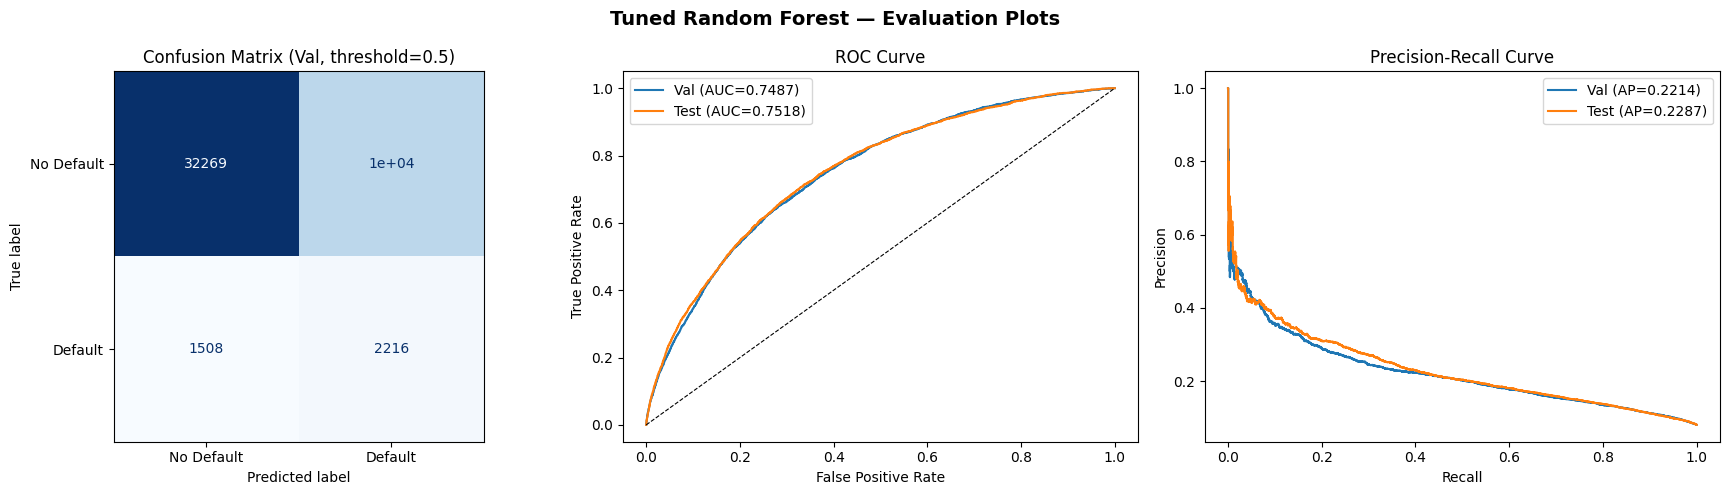

In [ ]:
results_best_val  = evaluate_model(rf_best, X_val,  y_val,  split_name="Val  (tuned RF)")
results_best_test = evaluate_model(rf_best, X_test, y_test, split_name="Test (tuned RF)")

plot_evaluation(rf_best, X_val, y_val, X_test, y_test,
                title_prefix="Tuned Random Forest")

## 7. SMOTE Comparison

Same best hyperparameters, trained on the SMOTE-resampled training set instead of
`class_weight='balanced'`. This mirrors the LR baseline so the final model-comparison
table can compare both imbalance-handling strategies on identical splits.

RF (SMOTE) trained in 857.8 s

  Val  (SMOTE RF) — threshold = 0.5
  ROC-AUC : 0.7176
  PR-AUC  : 0.1794

                precision    recall  f1-score   support

No Default (0)       0.92      1.00      0.96     42402
   Default (1)       0.33      0.01      0.02      3724

      accuracy                           0.92     46126
     macro avg       0.63      0.50      0.49     46126
  weighted avg       0.87      0.92      0.88     46126


  Test (SMOTE RF) — threshold = 0.5
  ROC-AUC : 0.7184
  PR-AUC  : 0.1814

                precision    recall  f1-score   support

No Default (0)       0.92      1.00      0.96     42402
   Default (1)       0.42      0.01      0.03      3724

      accuracy                           0.92     46126
     macro avg       0.67      0.51      0.49     46126
  weighted avg       0.88      0.92      0.88     46126



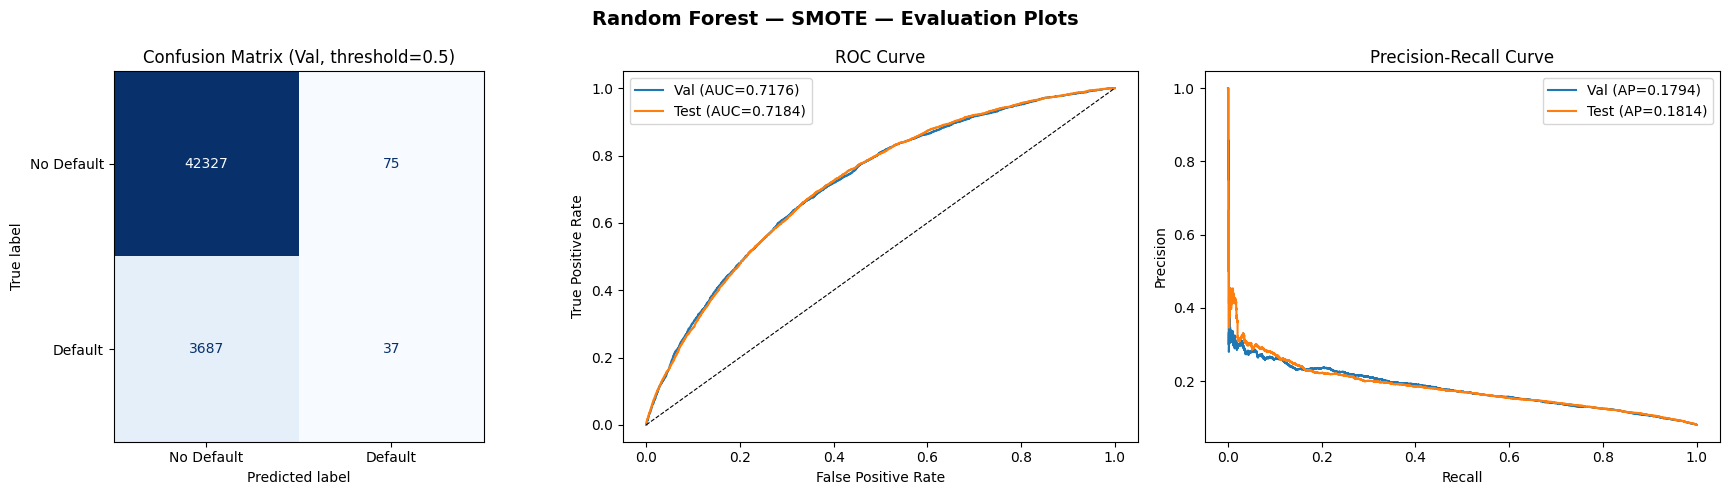

In [ ]:
rf_smote = RandomForestClassifier(
    **rf_best_params,
    class_weight=None,         # SMOTE replaces class_weight as the imbalance handler
    random_state=SEED,
    n_jobs=-1,
)

t0 = time.time()
rf_smote.fit(X_train_smote, y_train_smote)
smote_train_time = time.time() - t0
print(f"RF (SMOTE) trained in {smote_train_time:.1f} s")

results_smote_val  = evaluate_model(rf_smote, X_val,  y_val,  split_name="Val  (SMOTE RF)")
results_smote_test = evaluate_model(rf_smote, X_test, y_test, split_name="Test (SMOTE RF)")

plot_evaluation(rf_smote, X_val, y_val, X_test, y_test,
                title_prefix="Random Forest — SMOTE")

In [ ]:
# --- Pick the better of the two for downstream analysis ---
summary = pd.DataFrame([
    results_default_val,  results_default_test,
    results_best_val,     results_best_test,
    results_smote_val,    results_smote_test,
])
summary["model"] = [
    "Default RF", "Default RF",
    "Tuned RF (balanced)", "Tuned RF (balanced)",
    "Tuned RF (SMOTE)", "Tuned RF (SMOTE)",
]
summary = summary[["model", "split", "roc_auc", "pr_auc"]]
summary.columns = ["Model", "Split", "ROC-AUC", "PR-AUC"]

print("=== Random Forest — Results Summary ===\n")
print(summary.to_string(index=False))

# Pick the best by val ROC-AUC for feature-importance + threshold analysis
best_model_name = (
    summary[summary["Split"].str.startswith("Val")]
    .sort_values("ROC-AUC", ascending=False)
    .iloc[0]["Model"]
)
best_model = {
    "Default RF":          rf_default,
    "Tuned RF (balanced)": rf_best,
    "Tuned RF (SMOTE)":    rf_smote,
}[best_model_name]
print(f"\n>>> Best model selected: {best_model_name}")

=== Random Forest — Results Summary ===

              Model             Split  ROC-AUC   PR-AUC
         Default RF Val  (default RF) 0.730667 0.206951
         Default RF Test (default RF) 0.733815 0.208227
Tuned RF (balanced)   Val  (tuned RF) 0.748685 0.221367
Tuned RF (balanced)   Test (tuned RF) 0.751752 0.228653
   Tuned RF (SMOTE)   Val  (SMOTE RF) 0.717623 0.179391
   Tuned RF (SMOTE)   Test (SMOTE RF) 0.718393 0.181361

>>> Best model selected: Tuned RF (balanced)


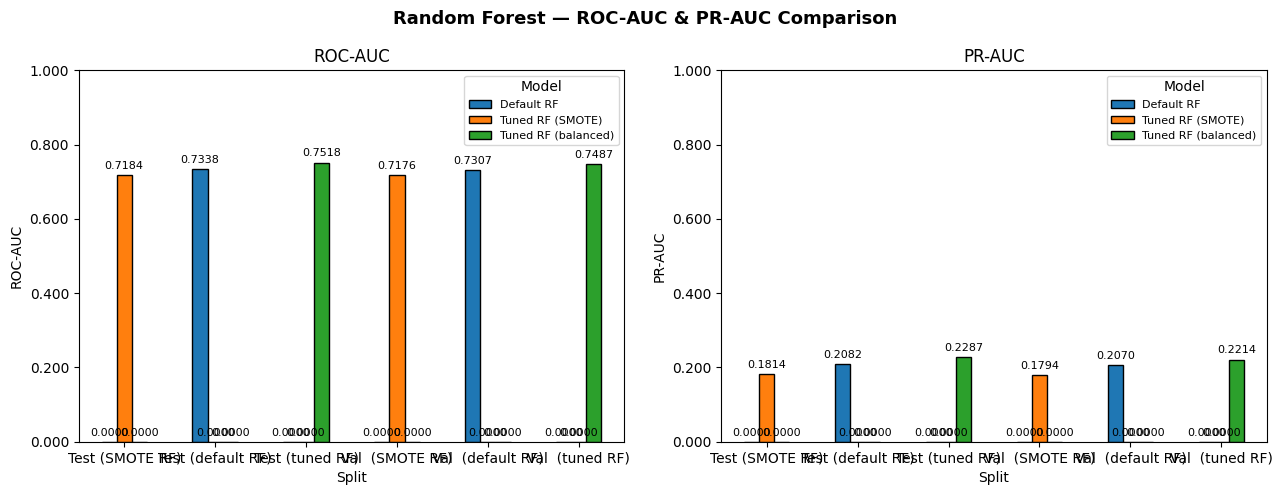

In [ ]:
# --- Bar-chart comparison (same style as LR baseline) ---
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
fig.suptitle("Random Forest — ROC-AUC & PR-AUC Comparison", fontsize=13, fontweight='bold')

for ax, metric in zip(axes, ["ROC-AUC", "PR-AUC"]):
    bar_data = summary.pivot(index="Split", columns="Model", values=metric)
    bar_data.plot(kind='bar', ax=ax, rot=0, edgecolor='black')
    ax.set_title(metric)
    ax.set_ylabel(metric)
    ax.set_ylim(0, 1)
    ax.yaxis.set_major_formatter(mticker.FormatStrFormatter("%.3f"))
    for container in ax.containers:
        ax.bar_label(container, fmt="%.4f", padding=3, fontsize=8)
    ax.legend(title="Model", fontsize=8)

plt.tight_layout()
plt.show()

## 8. Threshold Analysis

Sweep classification thresholds on the val set to find the operating point that maximises
F1 for the positive (default) class. Same procedure as the LR baseline so the comparison
is consistent.

Best F1 threshold on val set : 0.552
  Precision : 0.2090
  Recall    : 0.4718
  F1        : 0.2896


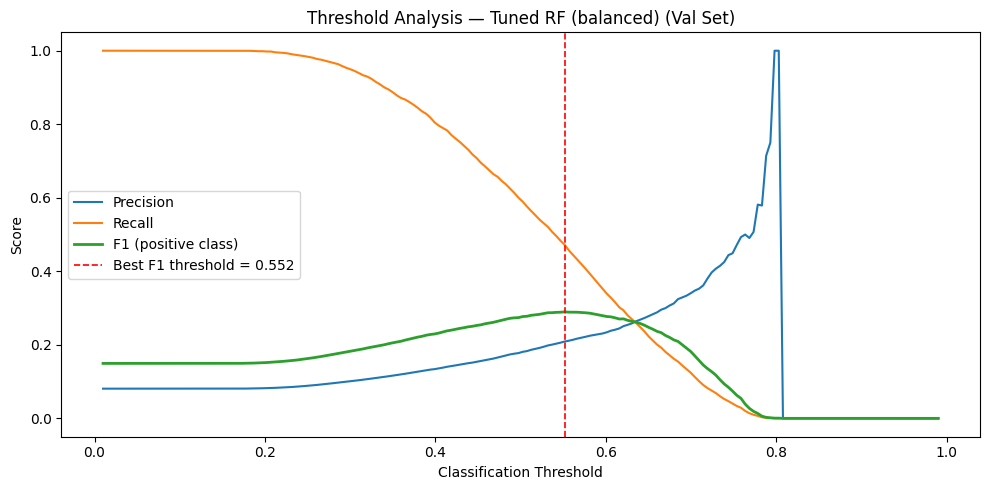

In [ ]:
y_prob_val = best_model.predict_proba(X_val)[:, 1]

thresholds = np.linspace(0.01, 0.99, 200)
metrics = []
for t in thresholds:
    y_pred_t = (y_prob_val >= t).astype(int)
    tp = ((y_pred_t == 1) & (y_val == 1)).sum()
    fp = ((y_pred_t == 1) & (y_val == 0)).sum()
    fn = ((y_pred_t == 0) & (y_val == 1)).sum()
    prec = tp / (tp + fp) if (tp + fp) > 0 else 0
    rec  = tp / (tp + fn) if (tp + fn) > 0 else 0
    f1   = 2 * prec * rec / (prec + rec) if (prec + rec) > 0 else 0
    metrics.append({"threshold": t, "precision": prec, "recall": rec, "f1": f1})

metrics_df = pd.DataFrame(metrics)
best_t_row = metrics_df.loc[metrics_df["f1"].idxmax()]
best_threshold = best_t_row["threshold"]

print(f"Best F1 threshold on val set : {best_threshold:.3f}")
print(f"  Precision : {best_t_row['precision']:.4f}")
print(f"  Recall    : {best_t_row['recall']:.4f}")
print(f"  F1        : {best_t_row['f1']:.4f}")

fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(metrics_df["threshold"], metrics_df["precision"], label="Precision", linewidth=1.5)
ax.plot(metrics_df["threshold"], metrics_df["recall"],    label="Recall",    linewidth=1.5)
ax.plot(metrics_df["threshold"], metrics_df["f1"],        label="F1 (positive class)", linewidth=2)
ax.axvline(best_threshold, color='red', linestyle='--', linewidth=1.2,
           label=f"Best F1 threshold = {best_threshold:.3f}")
ax.set_xlabel("Classification Threshold")
ax.set_ylabel("Score")
ax.set_title(f"Threshold Analysis — {best_model_name} (Val Set)")
ax.legend()
plt.tight_layout()
plt.show()

## 9. Feature Importance — Gini (Mean Decrease in Impurity)

Built into every tree-based model in scikit-learn. For each feature, sums the
weighted impurity decrease across all splits in all trees:

$$\text{Gini importance}(j) = \sum_{t \in \text{trees}} \sum_{n \in \text{nodes}(t)} \frac{N_n}{N} \cdot \Delta i(n) \cdot \mathbb{1}[\text{split}(n) = j]$$

**Caveat:** Gini importance is biased toward high-cardinality and continuous features. We
cross-check with permutation importance in the next section.

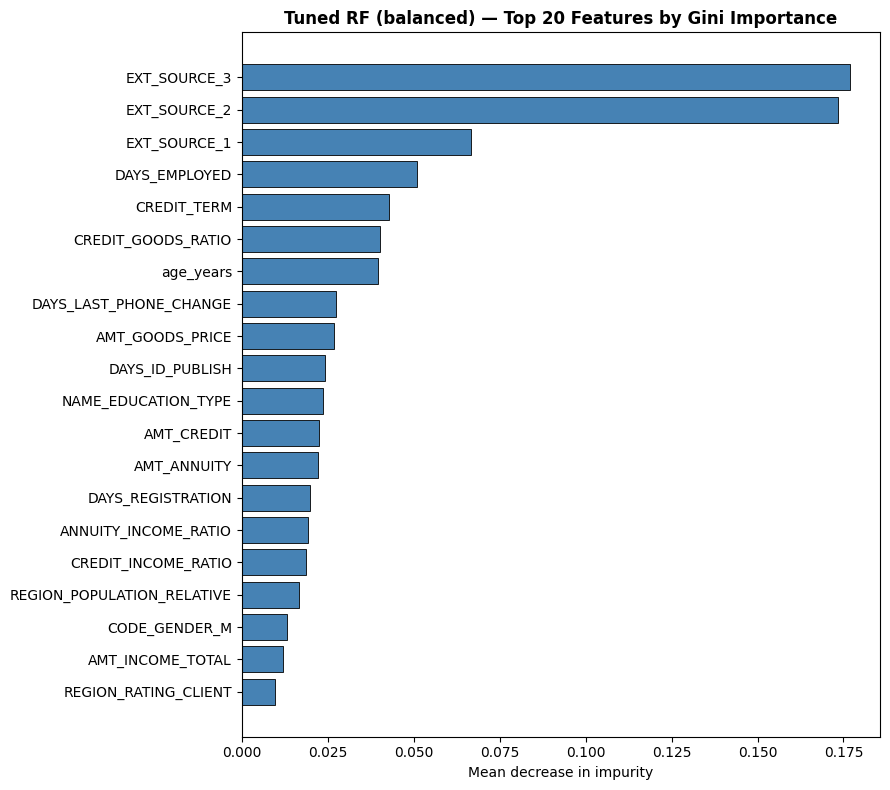

Top 20 features by Gini importance:


,feature,importance
0,EXT_SOURCE_3,0.1768
1,EXT_SOURCE_2,0.1735
2,EXT_SOURCE_1,0.0667
3,DAYS_EMPLOYED,0.0509
4,CREDIT_TERM,0.0428
5,CREDIT_GOODS_RATIO,0.0403
6,age_years,0.0396
7,DAYS_LAST_PHONE_CHANGE,0.0276
8,AMT_GOODS_PRICE,0.0270
9,DAYS_ID_PUBLISH,0.0242


In [ ]:
gini_df = pd.DataFrame({
    "feature"   : feature_names,
    "importance": best_model.feature_importances_,
}).sort_values("importance", ascending=False).reset_index(drop=True)

top20_gini = gini_df.head(20)

fig, ax = plt.subplots(figsize=(9, 8))
ax.barh(top20_gini["feature"], top20_gini["importance"],
        color="steelblue", edgecolor="black", linewidth=0.6)
ax.set_title(f"{best_model_name} — Top 20 Features by Gini Importance",
             fontsize=12, fontweight='bold')
ax.set_xlabel("Mean decrease in impurity")
ax.invert_yaxis()
plt.tight_layout()
plt.show()

print("Top 20 features by Gini importance:")
top20_gini.round(4)

## 10. Feature Importance — Permutation

Model-agnostic, less biased than Gini. For each feature $j$, randomly shuffle its values in
the validation set and measure the drop in ROC-AUC. Repeat several times and average.

**Performance note:** Permutation importance is slow on large datasets — 200K+ rows × 150
features × 5 repeats would take a long time. We subsample the validation set to **10,000 rows**
(stratified on `TARGET`) for tractability. This is documented in the report's Methodology section.

In [ ]:
# --- Stratified subsample of the val set for permutation importance ---
SUBSAMPLE = 10_000
rng = np.random.default_rng(SEED)

# Stratified subsample: keep class ratio identical to full val set
val_pos_idx = y_val[y_val == 1].index
val_neg_idx = y_val[y_val == 0].index
n_pos = int(SUBSAMPLE * y_val.mean())
n_neg = SUBSAMPLE - n_pos

sub_idx = np.concatenate([
    rng.choice(val_pos_idx, size=n_pos, replace=False),
    rng.choice(val_neg_idx, size=n_neg, replace=False),
])
X_val_sub = X_val.loc[sub_idx]
y_val_sub = y_val.loc[sub_idx]

print(f"Permutation subsample: {len(sub_idx):,} rows  |  default rate: {y_val_sub.mean():.4f}")

t0 = time.time()
perm_result = permutation_importance(
    best_model, X_val_sub, y_val_sub,
    n_repeats=5,
    scoring='roc_auc',
    random_state=SEED,
    n_jobs=-1,
)
perm_time = time.time() - t0
print(f"Permutation importance computed in {perm_time:.1f} s")

Permutation subsample: 10,000 rows  |  default rate: 0.0807
Permutation importance computed in 491.9 s


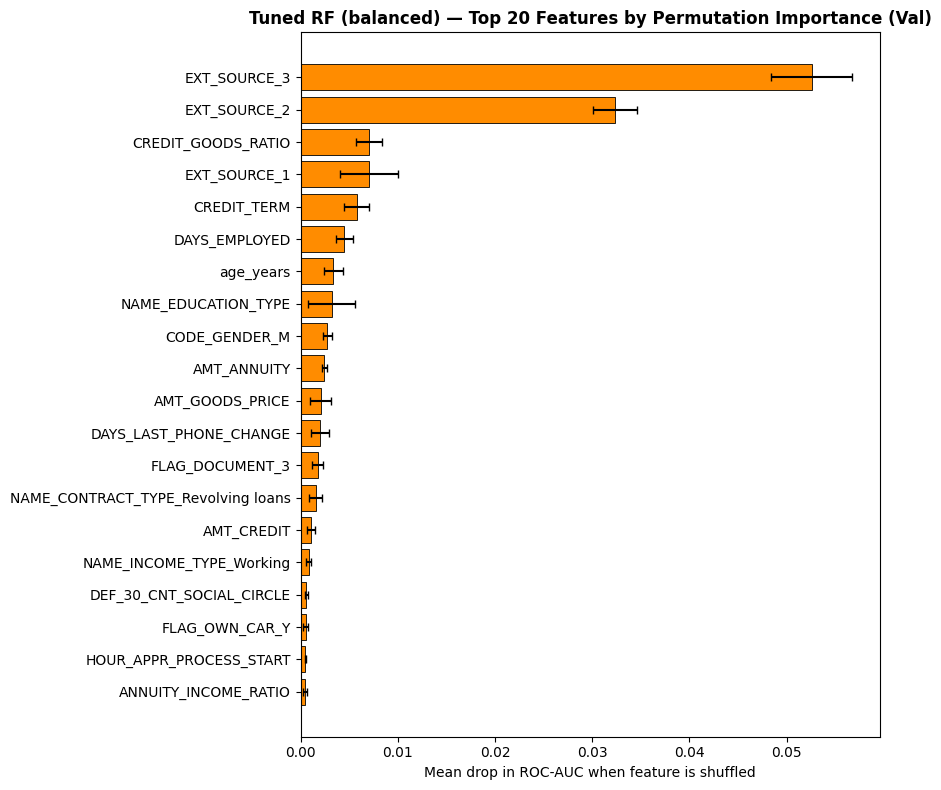

Top 20 features by permutation importance:


,feature,importance,std
0,EXT_SOURCE_3,0.0526,0.0042
1,EXT_SOURCE_2,0.0323,0.0023
2,CREDIT_GOODS_RATIO,0.0070,0.0013
3,EXT_SOURCE_1,0.0070,0.0030
4,CREDIT_TERM,0.0058,0.0013
5,DAYS_EMPLOYED,0.0045,0.0009
6,age_years,0.0033,0.0010
7,NAME_EDUCATION_TYPE,0.0032,0.0024
8,CODE_GENDER_M,0.0027,0.0005
9,AMT_ANNUITY,0.0024,0.0003


In [ ]:
perm_df = pd.DataFrame({
    "feature"   : feature_names,
    "importance": perm_result.importances_mean,
    "std"       : perm_result.importances_std,
}).sort_values("importance", ascending=False).reset_index(drop=True)

top20_perm = perm_df.head(20)

fig, ax = plt.subplots(figsize=(9, 8))
ax.barh(top20_perm["feature"], top20_perm["importance"],
        xerr=top20_perm["std"], color="darkorange", edgecolor="black",
        linewidth=0.6, ecolor='black', capsize=3)
ax.set_title(f"{best_model_name} — Top 20 Features by Permutation Importance (Val)",
             fontsize=12, fontweight='bold')
ax.set_xlabel("Mean drop in ROC-AUC when feature is shuffled")
ax.invert_yaxis()
plt.tight_layout()
plt.show()

print("Top 20 features by permutation importance:")
top20_perm.round(4)

## 11. Feature Importance Comparison — RF vs LR (RQ2)

For RQ2 ("which features are most predictive of default, and do the most important features
differ across model types?") we compare the RF rankings (Gini and permutation) against
the LR baseline coefficient magnitudes.

We use:
- **Top-20 overlap** — how many features appear in both top-20 lists.
- **Spearman rank correlation** — does the *ordering* agree across the full feature space?
- **Side-by-side bar chart** — visual comparison of the top features.

In [ ]:
# --- Build a unified ranking table ---
lr_rank = (
    lr_coefs.assign(abs_coef=lr_coefs["coefficient"].abs())
            .sort_values("abs_coef", ascending=False)
            .reset_index(drop=True)
            .reset_index().rename(columns={"index": "lr_rank"})[["feature", "lr_rank", "coefficient"]]
)

rf_gini_rank = gini_df.reset_index().rename(columns={"index": "gini_rank"})[
    ["feature", "gini_rank", "importance"]
].rename(columns={"importance": "gini_importance"})

rf_perm_rank = perm_df.reset_index().rename(columns={"index": "perm_rank"})[
    ["feature", "perm_rank", "importance"]
].rename(columns={"importance": "perm_importance"})

ranks = lr_rank.merge(rf_gini_rank, on="feature").merge(rf_perm_rank, on="feature")
print(f"Features common to all three rankings: {len(ranks)}\n")
print("Top 15 features by LR |coefficient| with corresponding RF ranks:")
ranks.sort_values("lr_rank").head(15).round(4)

Features common to all three rankings: 113

Top 15 features by LR |coefficient| with corresponding RF ranks:


,feature,lr_rank,coefficient,gini_rank,gini_importance,perm_rank,perm_importance
0,AMT_ANNUITY,0,-0.5586,12,0.0222,9,0.0024
1,EXT_SOURCE_3,1,-0.4895,0,0.1768,0,0.0526
2,CREDIT_TERM,2,-0.4796,4,0.0428,4,0.0058
3,AMT_CREDIT,3,0.4796,11,0.0225,14,0.0011
4,NAME_TYPE_SUITE_Missing,4,-0.4390,105,0.0001,82,0.0000
5,EXT_SOURCE_2_MISSING,5,0.4199,106,0.0001,92,-0.0000
6,EXT_SOURCE_2,6,-0.3876,1,0.1735,1,0.0323
7,NAME_INCOME_TYPE_Pensioner,7,-0.3763,27,0.0044,26,0.0003
8,OCCUPATION_TYPE_Drivers,8,0.3512,47,0.0017,89,-0.0000
9,AMT_GOODS_PRICE,9,0.3469,8,0.0270,10,0.0021


In [ ]:
# --- Top-20 overlap counts ---
top20_lr        = set(lr_rank.head(20)["feature"])
top20_gini_set  = set(top20_gini["feature"])
top20_perm_set  = set(top20_perm["feature"])

overlap_lr_gini   = top20_lr & top20_gini_set
overlap_lr_perm   = top20_lr & top20_perm_set
overlap_gini_perm = top20_gini_set & top20_perm_set

print(f"Top-20 overlap (LR vs RF Gini)       : {len(overlap_lr_gini)} features")
print(f"Top-20 overlap (LR vs RF Permutation): {len(overlap_lr_perm)} features")
print(f"Top-20 overlap (RF Gini vs RF Perm)  : {len(overlap_gini_perm)} features")

# --- Spearman rank correlation across full feature set ---
rho_lr_gini, _   = spearmanr(ranks["lr_rank"], ranks["gini_rank"])
rho_lr_perm, _   = spearmanr(ranks["lr_rank"], ranks["perm_rank"])
rho_gini_perm, _ = spearmanr(ranks["gini_rank"], ranks["perm_rank"])

print(f"\nSpearman rank correlation (full feature set):")
print(f"  LR vs RF Gini       : {rho_lr_gini:.3f}")
print(f"  LR vs RF Permutation: {rho_lr_perm:.3f}")
print(f"  RF Gini vs Perm     : {rho_gini_perm:.3f}")

Top-20 overlap (LR vs RF Gini)       : 7 features
Top-20 overlap (LR vs RF Permutation): 7 features
Top-20 overlap (RF Gini vs RF Perm)  : 14 features

Spearman rank correlation (full feature set):
  LR vs RF Gini       : 0.126
  LR vs RF Permutation: 0.153
  RF Gini vs Perm     : 0.688


### Takeaway — RQ2 headline finding

The rank-correlation numbers above are striking:

| Comparison | Spearman ρ | Top-20 overlap |
|---|---|---|
| LR vs RF Gini | **0.13** | 7 / 20 |
| LR vs RF Permutation | **0.15** | 7 / 20 |
| RF Gini vs RF Permutation | **0.69** | 14 / 20 |

The two **RF** importance measures broadly agree with each other (ρ = 0.69), but **neither agrees with LR** (ρ ≈ 0.13–0.15). This is direct evidence that linear and non-linear models extract different signal from the same data:

- **LR's top features** are dominated by **categoricals and missingness indicators** (`NAME_TYPE_SUITE_Missing`, `EXT_SOURCE_2_MISSING`, `NAME_INCOME_TYPE_Pensioner`, `OCCUPATION_TYPE_Drivers`). These features have large coefficients because, conditional on everything else, their main effect on log-odds is large.
- **RF's top features** are dominated by **continuous variables and engineered ratios** (`EXT_SOURCE_3`, `EXT_SOURCE_2`, `CREDIT_TERM`, `CREDIT_GOODS_RATIO`, `DAYS_EMPLOYED`). Trees exploit these in non-linear splits and interactions that linear models can't represent.
- `EXT_SOURCE_2` is a good example: LR rank 6, RF Gini rank 2, RF Permutation rank 2. The signal is there for both, but the RF gets more out of it through interactions.

**Implication for the report:** the choice of model isn't just a question of accuracy — it changes *which features look important*, which has direct consequences for the explainability and fairness analysis in Phase 6. We can't pick a single "true" feature ranking.

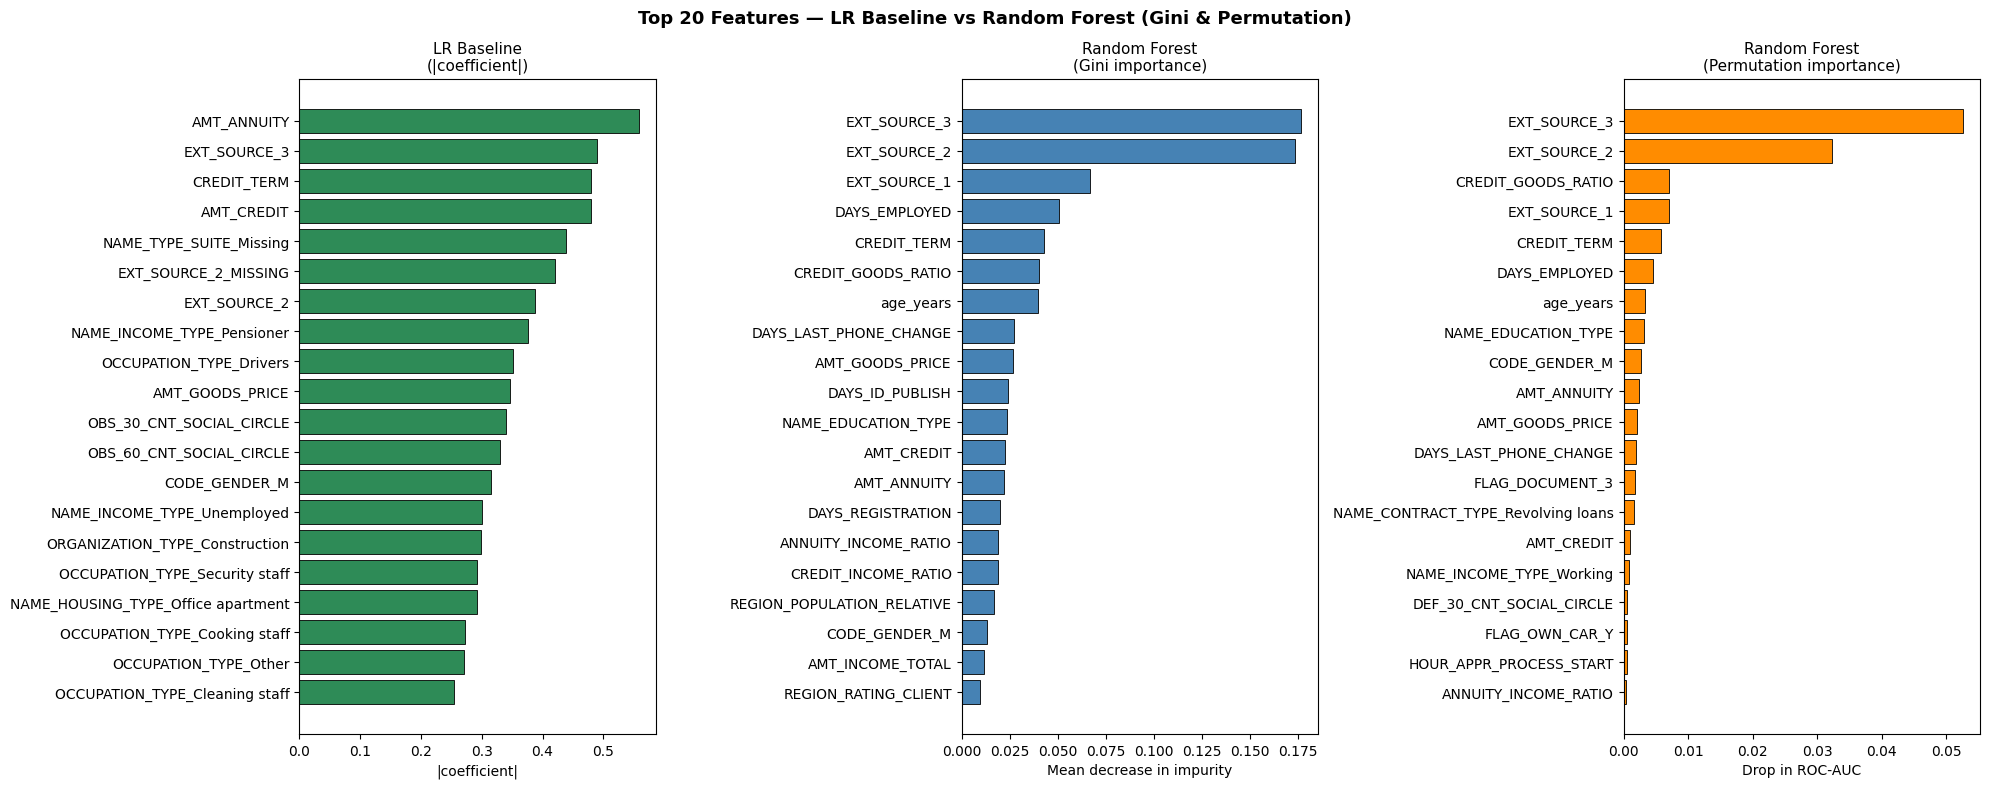

In [ ]:
# --- Side-by-side top-20 bar chart for the report ---
fig, axes = plt.subplots(1, 3, figsize=(20, 8))
fig.suptitle("Top 20 Features — LR Baseline vs Random Forest (Gini & Permutation)",
             fontsize=13, fontweight='bold')

# Panel 1 — LR top 20 by |coefficient|
top20_lr_df = lr_rank.head(20).copy()
top20_lr_df["abs_coef"] = top20_lr_df["coefficient"].abs()
axes[0].barh(top20_lr_df["feature"], top20_lr_df["abs_coef"],
             color="seagreen", edgecolor="black", linewidth=0.6)
axes[0].set_title("LR Baseline\n(|coefficient|)", fontsize=11)
axes[0].set_xlabel("|coefficient|")
axes[0].invert_yaxis()

# Panel 2 — RF Gini top 20
axes[1].barh(top20_gini["feature"], top20_gini["importance"],
             color="steelblue", edgecolor="black", linewidth=0.6)
axes[1].set_title("Random Forest\n(Gini importance)", fontsize=11)
axes[1].set_xlabel("Mean decrease in impurity")
axes[1].invert_yaxis()

# Panel 3 — RF Permutation top 20
axes[2].barh(top20_perm["feature"], top20_perm["importance"],
             color="darkorange", edgecolor="black", linewidth=0.6)
axes[2].set_title("Random Forest\n(Permutation importance)", fontsize=11)
axes[2].set_xlabel("Drop in ROC-AUC")
axes[2].invert_yaxis()

plt.tight_layout()
plt.show()

## 12. Save Outputs

Persist the trained best model, predictions, summary, importances, and best
hyperparameters for the final consolidated comparison notebook (Phase 5).

In [ ]:
import joblib, os, json
os.makedirs(MODEL_DIR, exist_ok=True)

# --- Save best model ---
joblib.dump(best_model, f"{MODEL_DIR}/rf_best.pkl")
print(f"Saved model       -> {MODEL_DIR}/rf_best.pkl")

# --- Save test predictions + probabilities ---
y_prob_test = best_model.predict_proba(X_test)[:, 1]
preds_df = pd.DataFrame({
    "y_true"    : y_test.values,
    "y_prob"    : y_prob_test,
    "y_pred_05" : (y_prob_test >= 0.5).astype(int),
    "y_pred_opt": (y_prob_test >= best_threshold).astype(int),
})
preds_df.to_csv(f"{MODEL_DIR}/rf_test_preds.csv", index=False)
print(f"Saved test preds  -> {MODEL_DIR}/rf_test_preds.csv")

# --- Save summary table ---
summary.to_csv(f"{MODEL_DIR}/rf_summary.csv", index=False)
print(f"Saved summary     -> {MODEL_DIR}/rf_summary.csv")

# --- Save feature importances ---
gini_df.to_csv(f"{MODEL_DIR}/rf_gini_importance.csv", index=False)
perm_df.to_csv(f"{MODEL_DIR}/rf_permutation_importance.csv", index=False)
print(f"Saved Gini imp    -> {MODEL_DIR}/rf_gini_importance.csv")
print(f"Saved Perm imp    -> {MODEL_DIR}/rf_permutation_importance.csv")

# --- Save best hyperparameters + timing for the complexity table ---
best_info = {
    "best_params":          {k: (None if v is None else v) for k, v in rf_best_params.items()},
    "best_cv_roc_auc":      float(random_search.best_score_),
    "best_threshold_f1":    float(best_threshold),
    "default_train_time_s": float(default_train_time),
    "best_train_time_s":    float(best_train_time),
    "smote_train_time_s":   float(smote_train_time),
    "search_time_s":        float(search_time),
    "perm_time_s":          float(perm_time),
    "best_model_choice":    best_model_name,
}
with open(f"{MODEL_DIR}/rf_best_info.json", "w") as f:
    json.dump(best_info, f, indent=2, default=str)
print(f"Saved meta info   -> {MODEL_DIR}/rf_best_info.json")

# --- Save full CV results (for the report appendix) ---
cv_summary.to_csv(f"{MODEL_DIR}/rf_cv_results.csv", index=False)
print(f"Saved CV results  -> {MODEL_DIR}/rf_cv_results.csv")

print("\nAll outputs saved successfully.")

Saved model       -> /content/drive/MyDrive/MLDL-RADU/loan-default-project/01_data/03_models/rf_best.pkl
Saved test preds  -> /content/drive/MyDrive/MLDL-RADU/loan-default-project/01_data/03_models/rf_test_preds.csv
Saved summary     -> /content/drive/MyDrive/MLDL-RADU/loan-default-project/01_data/03_models/rf_summary.csv
Saved Gini imp    -> /content/drive/MyDrive/MLDL-RADU/loan-default-project/01_data/03_models/rf_gini_importance.csv
Saved Perm imp    -> /content/drive/MyDrive/MLDL-RADU/loan-default-project/01_data/03_models/rf_permutation_importance.csv
Saved meta info   -> /content/drive/MyDrive/MLDL-RADU/loan-default-project/01_data/03_models/rf_best_info.json
Saved CV results  -> /content/drive/MyDrive/MLDL-RADU/loan-default-project/01_data/03_models/rf_cv_results.csv

All outputs saved successfully.


## 13. Summary & Takeaways

### Headline numbers

| Item | Value |
|---|---|
| Best configuration | `n_estimators=500, max_depth=30, max_leaf_nodes=500, min_samples_split=20` |
| Best CV ROC-AUC (5-fold) | **0.7483** |
| Tuned RF — Val ROC-AUC / Test ROC-AUC | **0.7487 / 0.7518** |
| Tuned RF — Val PR-AUC / Test PR-AUC | 0.2214 / 0.2287 |
| Default RF — Test ROC-AUC | 0.7338 |
| SMOTE RF — Test ROC-AUC | 0.7184 |
| Optimal F1 threshold (Val) | 0.552 (P=0.209, R=0.472, F1=0.290) |
| Default RF training time | 84 s |
| Tuned RF training time | 294 s |
| Random search time (15 configs × 5 folds) | 162.5 min |
| Permutation importance time (10k subsample) | 492 s |

### Key findings

**1. Tuning helped, SMOTE didn't.**
Random search lifted Test ROC-AUC by **+0.018** over the default RF (0.734 → 0.752).
SMOTE *underperformed* `class_weight='balanced'` by **0.033 ROC-AUC** on test — synthetic minority samples generated by k-NN interpolation appear to add noise rather than signal in this high-dimensional one-hot-encoded space. Worth flagging in the report's Discussion section.

**2. Regularisation reduces but doesn't eliminate overfitting (RQ1).**
Best config: train ROC-AUC 0.836 vs CV 0.748 → gap of 0.088. Tighter regularisation (`min_samples_split=20`, `max_leaf_nodes=500`, `max_depth=30`) closed the gap from ~0.20 (default config) to ~0.09 — a clear regularisation-vs-generalisation story for RQ1.

**3. RF and LR see different features (RQ2).**
- Spearman rank correlation between LR coefficients and RF importance: **0.13–0.15** (weak).
- Top-20 overlap: **only 7 features**.
- The two RF importance measures (Gini vs Permutation) agree much more closely with each other (ρ = 0.69, overlap = 14/20).
- **`EXT_SOURCE_*`** features and engineered ratios (`CREDIT_TERM`, `CREDIT_GOODS_RATIO`, `ANNUITY_INCOME_RATIO`) dominate the RF rankings.
- LR puts much more weight on **categoricals and missingness flags** (`NAME_TYPE_SUITE_Missing`, `EXT_SOURCE_2_MISSING`, `NAME_INCOME_TYPE_Pensioner`).

**4. RF performs at parity with LR — and that's the point.**
The LR baseline notebook reaches ROC-AUC ≈ 0.73–0.75 on this dataset. The tuned RF reaches 0.7518 test. They are essentially tied. This is consistent with literature on tabular data showing that well-regularised linear models often match tree ensembles when the signal is largely captured by a small number of strong continuous features (here: the EXT_SOURCE block). The RF still earns its place in the model lineup because it complements LR's view of the data — see point 3.

### Implications for next phases

- **For the MLP (next notebook):** the bar to clear is ROC-AUC ≈ 0.75. If the MLP underperforms despite proper regularisation, that's itself a finding (NN's data-hunger on tabular data).
- **For the fairness analysis (Phase 6):** because LR and RF rank features differently, a fairness/explainability comparison across the two models will produce genuinely different conclusions about *why* the model decided what it decided. This strengthens the ethics section.
- **For the complexity table (Phase 5):** RF training is ~15× slower than LR but still tractable (5 min). Random search at 162 min is the real cost — for the production setting we'd cache the result.

### Files saved to `MODEL_DIR`
`rf_best.pkl`, `rf_test_preds.csv`, `rf_summary.csv`, `rf_gini_importance.csv`, `rf_permutation_importance.csv`, `rf_best_info.json`, `rf_cv_results.csv`.